# Reward-following walker on 4 biomes

Visualise the proposed task-0 reward on one map per biome.

**Potential** (HP lives in the state, so PBRS stays valid):

$$\Phi(s, hp) = -\text{ctg\_direct}(s) + \tfrac{c_\text{hp}}{c_\text{shape}} \cdot hp$$

**Per-step reward:**

$$r_t = -c_\text{step} + c_\text{shape}\cdot\bigl(\Phi(s', hp') - \Phi(s, hp)\bigr) + c_\text{reach}\cdot\mathbb{1}[\text{reached}]$$

Defaults: `step_penalty=0.02`, `shaping_coef=0.1`, `hp_coef=0.02`, `reach_bonus=30`, no `death_penalty`.

**HP model** (matches user's simplification of env): step onto a berry tile → HP snaps to `hp_max=100`; otherwise HP loses `drain[terrain]`. Deadly border is never chosen.

The walker is **greedy on `r_t`** (1-step lookahead) with a 4-cell tabu to break oscillations. It runs on 4 maps — one per biome — with spawn/target sampled ≥ 80 manhattan apart.

In [1]:
import sys, pathlib

REPO = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == 'notebooks' else pathlib.Path.cwd()
sys.path.insert(0, str(REPO / 'src'))

import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import dijkstra as scipy_dijkstra

from cogniland.envs.tile_effects import TileEffects

fx = TileEffects()
TERRAIN_NAMES = ['ocean', 'deep_water', 'water', 'beach', 'sandy',
                 'grassland', 'forest', 'rocky', 'mountains']
print('hp_max =', fx.hp_max, ' berry_heal =', fx.berry_heal)

hp_max = 100  berry_heal = 10


In [2]:
# ------------------------------------------------------------------
# Load val maps and pick one per biome with a far spawn/target pair.
# ------------------------------------------------------------------
maps = torch.load(REPO / 'data/maps/val.pt', map_location='cpu', weights_only=False)
BIOMES = ['balanced', 'archipelago', 'grassland', 'highland']
MIN_DIST = 80   # manhattan distance between spawn and target

def first_map_in_biome(biome):
    for i, b in enumerate(maps['biomes']):
        if b == biome:
            return i
    raise ValueError(f'no map with biome {biome!r}')

def pick_spawn_target(terrain_idx, min_dist, seed):
    rng = np.random.default_rng(seed)
    valid = terrain_idx >= 0
    # Don't spawn directly on the worst terrain; prefer landable cells.
    safe = valid & ~np.isin(terrain_idx, [0, 1, 8])  # no ocean/deep_water/mountains
    rs, cs = np.where(safe)
    for _ in range(10000):
        i = rng.integers(0, len(rs)); j = rng.integers(0, len(rs))
        sr, sc, tr, tc = int(rs[i]), int(cs[i]), int(rs[j]), int(cs[j])
        if abs(sr - tr) + abs(sc - tc) >= min_dist:
            return (sr, sc), (tr, tc)
    raise RuntimeError('failed to sample a far spawn/target pair')

scenarios = []
for idx, biome in enumerate(BIOMES):
    mi = first_map_in_biome(biome)
    terrain = maps['terrain_idx'][mi].numpy()
    (sr, sc), (tr, tc) = pick_spawn_target(terrain, MIN_DIST, seed=idx)
    scenarios.append(dict(
        biome=biome, mi=mi,
        terrain=terrain,
        berries=maps['berry_mask'][mi].numpy(),
        rgb=maps['rgb'][mi].numpy(),
        spawn=(sr, sc), target=(tr, tc),
    ))

for s in scenarios:
    sr, sc = s['spawn']; tr, tc = s['target']
    print(f'{s["biome"]:12s} map={s["mi"]:3d}  spawn=({sr:3d},{sc:3d}) '
          f'target=({tr:3d},{tc:3d})  manhattan={abs(sr-tr)+abs(sc-tc):3d}  '
          f'berries={int(s["berries"].sum())}')

balanced     map=  0  spawn=( 36, 87) target=( 98, 64)  manhattan= 85  berries=54
archipelago  map=  4  spawn=( 63, 84) target=( 99, 29)  manhattan= 91  berries=34
grassland    map= 12  spawn=(109, 94) target=( 34, 20)  manhattan=149  berries=55
highland     map=  8  spawn=( 96, 56) target=( 23, 73)  manhattan= 90  berries=65


In [3]:
# ------------------------------------------------------------------
# Effective drain (no tool, matches env for this notebook) + cost graph.
# Edge (u -> v) cost = drain[terrain[v]]; berries -> 0; deadly disconnected.
# Mirror of env._build_cost_graph.
# ------------------------------------------------------------------
def drain_arr_no_tool():
    return np.array([fx.hp_drain[n] for n in TERRAIN_NAMES], dtype=np.float64)

def build_cost_graph(terrain_idx, berry_mask, hp_drain_arr):
    H, W = terrain_idx.shape
    cell_cost = np.full((H, W), np.inf, dtype=np.float64)
    valid = terrain_idx >= 0
    cell_cost[valid] = hp_drain_arr[terrain_idx[valid]]
    cell_cost[berry_mask & valid] = 0.0

    r_h, c_h = np.mgrid[0:H, 0:W - 1]
    src_h = (r_h * W + c_h).ravel()
    dst_h = (r_h * W + c_h + 1).ravel()
    r_v, c_v = np.mgrid[0:H - 1, 0:W]
    src_v = (r_v * W + c_v).ravel()
    dst_v = ((r_v + 1) * W + c_v).ravel()

    all_src = np.concatenate([src_h, dst_h, src_v, dst_v])
    all_dst = np.concatenate([dst_h, src_h, dst_v, src_v])
    all_cost = np.concatenate([
        cell_cost[r_h, c_h + 1].ravel(),
        cell_cost[r_h, c_h].ravel(),
        cell_cost[r_v + 1, c_v].ravel(),
        cell_cost[r_v, c_v].ravel(),
    ])
    finite = np.isfinite(all_cost)
    return csr_matrix(
        (all_cost[finite], (all_src[finite], all_dst[finite])),
        shape=(H * W, H * W),
    )

def compute_ctg_direct(terrain_idx, berry_mask, drain_arr, target_rc):
    """Dijkstra backwards from target on the HP-drain graph."""
    H, W = terrain_idx.shape
    G = build_cost_graph(terrain_idx, berry_mask, drain_arr)
    tr, tc = target_rc
    ctg = scipy_dijkstra(G.T, directed=True, indices=tr * W + tc)
    return ctg.reshape(H, W).astype(np.float32)

drain_none = drain_arr_no_tool()
print('drain (no tool):', dict(zip(TERRAIN_NAMES, drain_none.astype(int))))

drain (no tool): {'ocean': np.int64(8), 'deep_water': np.int64(5), 'water': np.int64(3), 'beach': np.int64(1), 'sandy': np.int64(1), 'grassland': np.int64(1), 'forest': np.int64(2), 'rocky': np.int64(6), 'mountains': np.int64(8)}


## Reward-greedy walker

At each step, pick the move that maximises the immediate reward

$$r_t = -c_\text{step} + c_\text{shape}\cdot(\Phi(s',hp')-\Phi(s,hp)) + c_\text{reach}\cdot\mathbb{1}[\text{reached}]$$

Short tabu list prevents 2-cell oscillations. Walker stops on target, death, or `max_steps`.

In [4]:
# ------------------------------------------------------------------
# Reward coefficients (from the design note)
# ------------------------------------------------------------------
STEP_PENALTY = 0.02
SHAPING_COEF = 0.10
HP_COEF      = 0.02          # r += hp_coef * Δhp    (same-sign as step_penalty scale)
REACH_BONUS  = 30.0
HP_MAX       = float(fx.hp_max)

# Ratio inside Phi: Phi(s, hp) = -ctg_direct(s) + (HP_COEF/SHAPING_COEF)*hp.
ALPHA = HP_COEF / SHAPING_COEF

def potential(ctg_s, hp):
    return -float(ctg_s) + ALPHA * float(hp)

def step_reward(ctg_s, ctg_sp, hp, hp_p, reached):
    dphi = potential(ctg_sp, hp_p) - potential(ctg_s, hp)
    return -STEP_PENALTY + SHAPING_COEF * dphi + REACH_BONUS * float(reached)

def reward_greedy_walk(ctg, terrain_idx, berry_mask, drain_arr,
                        spawn_rc, target_rc,
                        hp_init=HP_MAX, max_steps=500, tabu_len=4):
    H, W = terrain_idx.shape
    r, c = spawn_rc; tr, tc = target_rc
    hp = float(hp_init)
    path = [(r, c)]; hp_trace = [hp]; rew_trace = [0.0]
    recent = []

    for _ in range(max_steps):
        if (r, c) == (tr, tc) or hp <= 0:
            break
        best = None; best_r = -np.inf
        ctg_s = ctg[r, c]
        for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            nr, nc = r + dr, c + dc
            if not (0 <= nr < H and 0 <= nc < W) or (nr, nc) in recent:
                continue
            t = terrain_idx[nr, nc]
            if t < 0:
                continue
            ctg_sp = ctg[nr, nc]
            if not np.isfinite(ctg_sp):
                continue
            next_hp = HP_MAX if berry_mask[nr, nc] else max(hp - float(drain_arr[t]), 0.0)
            reached = (nr, nc) == (tr, tc)
            rt = step_reward(ctg_s, ctg_sp, hp, next_hp, reached)
            if rt > best_r:
                best_r = rt; best = (nr, nc, next_hp)
        if best is None:
            break
        r, c, hp = best
        path.append((r, c)); hp_trace.append(hp); rew_trace.append(best_r)
        recent.append((r, c))
        if len(recent) > tabu_len:
            recent.pop(0)
    return np.array(path), np.array(hp_trace), np.array(rew_trace)

## Results on 4 biomes

Rows are biomes. Left column: path on RGB map, coloured by HP (green → full, red → dying). Right column: HP trace (magenta squares = berry pickups) with cumulative reward overlaid.

balanced     steps= 90  final_hp= +26.0  min_hp= +26.0  berries= 1  reached=True  total_r= +36.24  ctg_spawn=  95.0
archipelago  steps=100  final_hp= +46.0  min_hp= +39.0  berries= 1  reached=True  total_r= +38.44  ctg_spawn= 115.0
grassland    steps=154  final_hp= +27.0  min_hp= +27.0  berries= 6  reached=True  total_r= +41.48  ctg_spawn= 160.0
highland     steps=117  final_hp= +80.0  min_hp= +46.0  berries= 3  reached=True  total_r= +43.38  ctg_spawn= 161.0


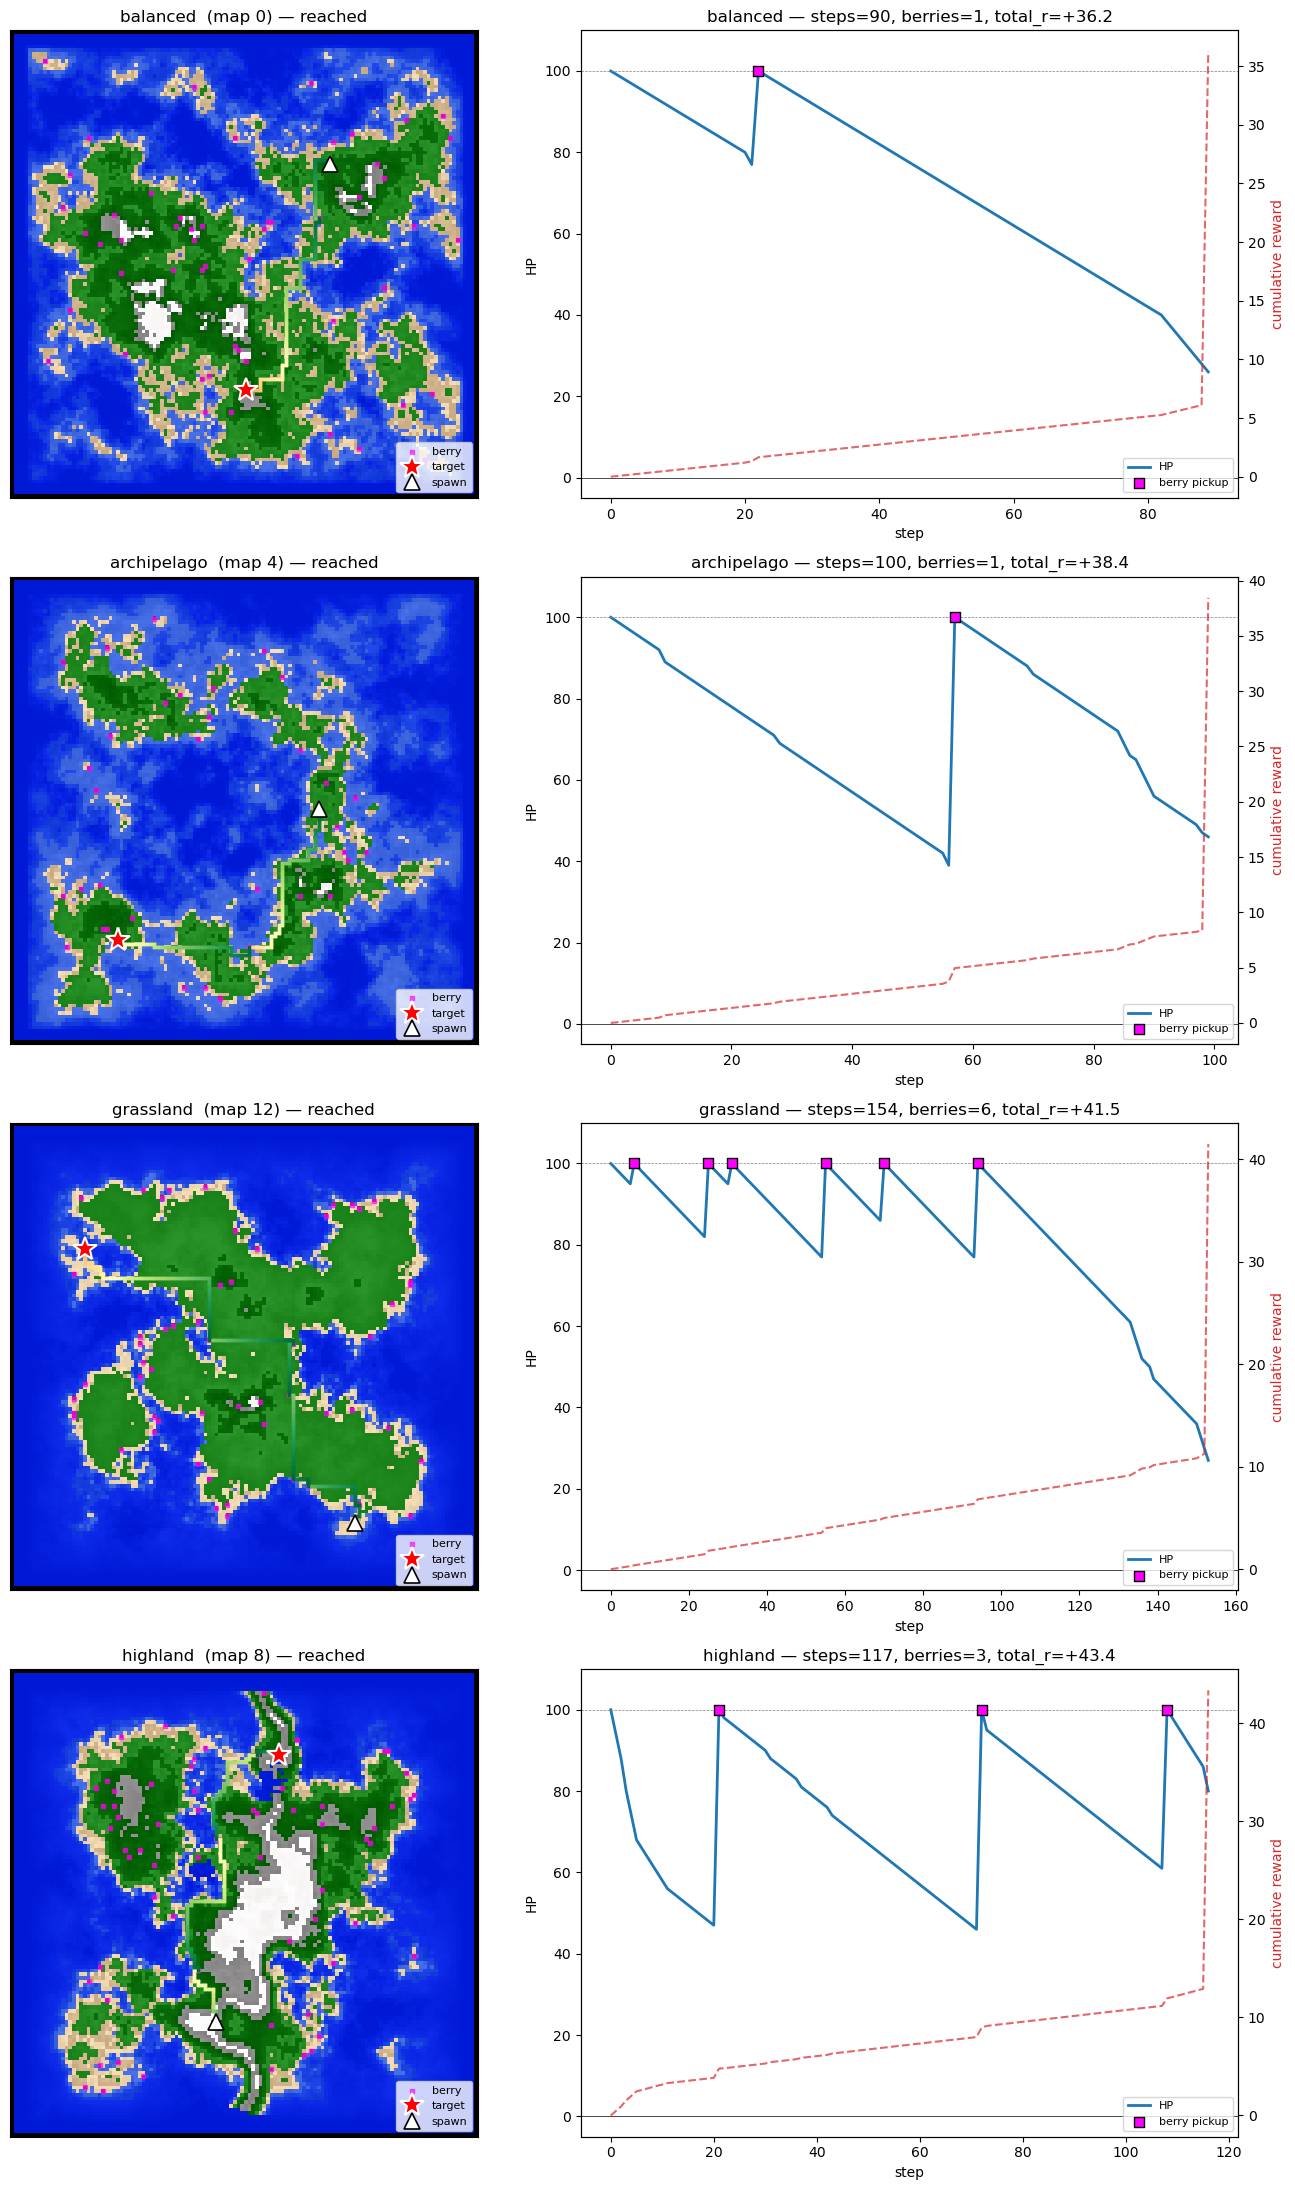

In [5]:
# ------------------------------------------------------------------
# Run walker on 4 biomes and summarise.
# ------------------------------------------------------------------
results = []
for sc in scenarios:
    ctg = compute_ctg_direct(sc['terrain'], sc['berries'], drain_none, sc['target'])
    path, hp_tr, r_tr = reward_greedy_walk(
        ctg, sc['terrain'], sc['berries'], drain_none,
        sc['spawn'], sc['target'],
    )
    reached = tuple(path[-1]) == sc['target'] and hp_tr[-1] > 0
    n_berries = int(sum(sc['berries'][r, c] for r, c in path))
    results.append(dict(**sc, ctg=ctg, path=path, hp=hp_tr, reward=r_tr,
                        reached=reached, n_berries=n_berries))
    print(f'{sc["biome"]:12s} steps={len(path):3d}  '
          f'final_hp={hp_tr[-1]:+6.1f}  min_hp={hp_tr.min():+6.1f}  '
          f'berries={n_berries:2d}  reached={reached}  '
          f'total_r={r_tr.sum():+7.2f}  ctg_spawn={ctg[sc["spawn"]]:6.1f}')

# ------------------------------------------------------------------
# Plot: 4 rows (biome) x 2 cols (path on map, HP trace + cum reward).
# ------------------------------------------------------------------
fig, axes = plt.subplots(4, 2, figsize=(14, 22))
cmap_hp = plt.cm.RdYlGn

for row, res in enumerate(results):
    ax_map = axes[row, 0]
    ax_map.imshow(res['rgb'])
    path = res['path']
    hp_norm = np.clip(res['hp'] / HP_MAX, 0.0, 1.0)
    for i in range(len(path) - 1):
        ax_map.plot(path[i:i+2, 1], path[i:i+2, 0], '-',
                     color=cmap_hp(hp_norm[i]), lw=2.5)
    br, bc = np.where(res['berries'])
    ax_map.scatter(bc, br, c='magenta', s=6, marker='s', alpha=0.6, label='berry')
    ax_map.plot(res['target'][1], res['target'][0], 'r*',
                  ms=18, mec='white', mew=1.5, label='target')
    ax_map.plot(res['spawn'][1], res['spawn'][0], 'w^',
                  ms=12, mec='black', mew=1.2, label='spawn')
    if not res['reached']:
        ax_map.plot(path[-1, 1], path[-1, 0], 'rx', ms=16, mew=4, label='stopped')
    tag = 'reached' if res['reached'] else f'FAILED (hp={res["hp"][-1]:.0f})'
    ax_map.set_title(f'{res["biome"]}  (map {res["mi"]}) — {tag}')
    ax_map.set_xticks([]); ax_map.set_yticks([])
    ax_map.legend(loc='lower right', fontsize=8)

    ax_hp = axes[row, 1]
    steps = np.arange(len(res['hp']))
    ax_hp.plot(steps, res['hp'], 'C0-', lw=2, label='HP')
    bsteps = [i for i, (r, c) in enumerate(path) if res['berries'][r, c]]
    if bsteps:
        ax_hp.scatter(bsteps, res['hp'][bsteps], c='magenta', s=60, marker='s',
                       edgecolor='k', zorder=5, label='berry pickup')
    ax_hp.axhline(0, color='k', lw=0.5); ax_hp.axhline(100, color='gray', lw=0.5, ls='--')
    ax_hp.set_xlabel('step'); ax_hp.set_ylabel('HP'); ax_hp.set_ylim(-5, 110)
    ax_r = ax_hp.twinx()
    ax_r.plot(steps, np.cumsum(res['reward']), 'C3--', lw=1.5, alpha=0.7, label='cum reward')
    ax_r.set_ylabel('cumulative reward', color='C3')
    ax_hp.set_title(
        f'{res["biome"]} — steps={len(path)}, berries={res["n_berries"]}, '
        f'total_r={res["reward"].sum():+.1f}'
    )
    ax_hp.legend(loc='lower right', fontsize=8)

plt.tight_layout(); plt.show()